# Przetwarzanie szeregów czasowych z Pandas

### Datetime

In [2]:
from datetime import datetime

now = datetime.now()
now

datetime.datetime(2026, 3, 21, 20, 23, 14, 445397)

In [3]:
#rok, miesiąc, dzień
now.year, now.month, now.day

(2026, 3, 21)

In [4]:
# różnica pomiędzy datami - okres
delta = datetime(2026, 1, 2) - datetime(2025, 7, 12, 8, 50)
delta

datetime.timedelta(days=173, seconds=54600)

In [5]:
delta.days

173

In [6]:
delta.seconds

54600

### Formatowanie daty

In [7]:
stamp = datetime(2026, 8, 3)
str(stamp)

'2026-08-03 00:00:00'

In [8]:
stamp.strftime("%Y-%m-%d")

'2026-08-03'

In [9]:
stamp.strftime("%Y-%d-%m")

'2026-03-08'

In [10]:
stamp.strftime("%Y-%d-%m %H:%M:%S")

'2026-03-08 00:00:00'

In [11]:
# dzień tygodn'2026-03-08 00:00:00ia
stamp.strftime("%A")

'Monday'

### Wykorzystanie Series i datetime jako narzędzi do przetwarzania szeregów czasowych

In [12]:
import pandas as pd
import numpy as np

dates = [datetime(2026, 1, 2), datetime(2026, 1, 3),
         datetime(2026, 1, 4), datetime(2026, 1, 5)]
ts = pd.Series(np.random.standard_normal(4), index=dates)
ts

2026-01-02    0.328999
2026-01-03    0.505594
2026-01-04    0.663215
2026-01-05   -0.271262
dtype: float64

In [13]:
ts.index

DatetimeIndex(['2026-01-02', '2026-01-03', '2026-01-04', '2026-01-05'], dtype='datetime64[ns]', freq=None)

In [14]:
# parametry statystyczne
ts.describe()

count    4.000000
mean     0.306637
std      0.408738
min     -0.271262
25%      0.178934
50%      0.417297
75%      0.545000
max      0.663215
dtype: float64

In [15]:
# operacje matematyczne na szeregach czasowych
ts + ts

2026-01-02    0.657998
2026-01-03    1.011189
2026-01-04    1.326430
2026-01-05   -0.542524
dtype: float64

In [16]:
# odwołanie się do próbki
ts['2026-01-04']

np.float64(0.663215205253907)

In [17]:
# odwołanie się do zakresu
ts['2026-01-02':'2026-01-03']

2026-01-02    0.328999
2026-01-03    0.505594
dtype: float64

In [18]:
# próbkowanie w dół
ts.resample('YE').mean()

2026-12-31    0.306637
Freq: YE-DEC, dtype: float64

In [19]:
# odwołanie się do wielu dat jednocześnie
ts['2026-01']

2026-01-02    0.328999
2026-01-03    0.505594
2026-01-04    0.663215
2026-01-05   -0.271262
dtype: float64

In [20]:
# przesunięcie
ts.shift(3)

2026-01-02         NaN
2026-01-03         NaN
2026-01-04         NaN
2026-01-05    0.328999
dtype: float64

In [21]:
# przesunięcie
ts.shift(-3)

2026-01-02   -0.271262
2026-01-03         NaN
2026-01-04         NaN
2026-01-05         NaN
dtype: float64

In [22]:
index = pd.date_range("2027-04-01", "2027-06-01")
index

DatetimeIndex(['2027-04-01', '2027-04-02', '2027-04-03', '2027-04-04',
               '2027-04-05', '2027-04-06', '2027-04-07', '2027-04-08',
               '2027-04-09', '2027-04-10', '2027-04-11', '2027-04-12',
               '2027-04-13', '2027-04-14', '2027-04-15', '2027-04-16',
               '2027-04-17', '2027-04-18', '2027-04-19', '2027-04-20',
               '2027-04-21', '2027-04-22', '2027-04-23', '2027-04-24',
               '2027-04-25', '2027-04-26', '2027-04-27', '2027-04-28',
               '2027-04-29', '2027-04-30', '2027-05-01', '2027-05-02',
               '2027-05-03', '2027-05-04', '2027-05-05', '2027-05-06',
               '2027-05-07', '2027-05-08', '2027-05-09', '2027-05-10',
               '2027-05-11', '2027-05-12', '2027-05-13', '2027-05-14',
               '2027-05-15', '2027-05-16', '2027-05-17', '2027-05-18',
               '2027-05-19', '2027-05-20', '2027-05-21', '2027-05-22',
               '2027-05-23', '2027-05-24', '2027-05-25', '2027-05-26',
      

In [23]:
pd.date_range(start="2027-04-01", periods=20)

DatetimeIndex(['2027-04-01', '2027-04-02', '2027-04-03', '2027-04-04',
               '2027-04-05', '2027-04-06', '2027-04-07', '2027-04-08',
               '2027-04-09', '2027-04-10', '2027-04-11', '2027-04-12',
               '2027-04-13', '2027-04-14', '2027-04-15', '2027-04-16',
               '2027-04-17', '2027-04-18', '2027-04-19', '2027-04-20'],
              dtype='datetime64[ns]', freq='D')

In [24]:
pd.date_range(end="2027-06-01", periods=20)

DatetimeIndex(['2027-05-13', '2027-05-14', '2027-05-15', '2027-05-16',
               '2027-05-17', '2027-05-18', '2027-05-19', '2027-05-20',
               '2027-05-21', '2027-05-22', '2027-05-23', '2027-05-24',
               '2027-05-25', '2027-05-26', '2027-05-27', '2027-05-28',
               '2027-05-29', '2027-05-30', '2027-05-31', '2027-06-01'],
              dtype='datetime64[ns]', freq='D')

In [25]:
# datowanie na koniec miesiąca
pd.date_range("2027-01-01", "2028-12-01", freq="BME")

DatetimeIndex(['2027-01-29', '2027-02-26', '2027-03-31', '2027-04-30',
               '2027-05-31', '2027-06-30', '2027-07-30', '2027-08-31',
               '2027-09-30', '2027-10-29', '2027-11-30', '2027-12-31',
               '2028-01-31', '2028-02-29', '2028-03-31', '2028-04-28',
               '2028-05-31', '2028-06-30', '2028-07-31', '2028-08-31',
               '2028-09-29', '2028-10-31', '2028-11-30'],
              dtype='datetime64[ns]', freq='BME')

In [26]:
from pandas.tseries.offsets import Day, MonthEnd
now = datetime(2026, 6, 22)

# modyfikacja daty
now - 10 * Day()

Timestamp('2026-06-12 00:00:00')

In [27]:
# koniec kolejnego miesiąca
now + MonthEnd(2)

Timestamp('2026-07-31 00:00:00')

In [28]:
import pytz

# strefa czasowa
tz = pytz.timezone("Europe/Warsaw")
tz

<DstTzInfo 'Europe/Warsaw' LMT+1:24:00 STD>

In [29]:
# czas letni
pd.date_range("2026-03-29 00:30", freq="H", periods=10, tz="Europe/Warsaw")

DatetimeIndex(['2026-03-29 00:30:00+01:00', '2026-03-29 01:30:00+01:00',
               '2026-03-29 03:30:00+02:00', '2026-03-29 04:30:00+02:00',
               '2026-03-29 05:30:00+02:00', '2026-03-29 06:30:00+02:00',
               '2026-03-29 07:30:00+02:00', '2026-03-29 08:30:00+02:00',
               '2026-03-29 09:30:00+02:00', '2026-03-29 10:30:00+02:00'],
              dtype='datetime64[ns, Europe/Warsaw]', freq='h')

In [30]:
# notowania giełdowe
ts = pd.Series(np.random.permutation(np.arange(len(dates))), index=dates)
ts.resample("5min").ohlc().ffill()

,open,high,low,close
2026-01-02 00:00:00,0.0,0.0,0.0,0.0
2026-01-02 00:05:00,0.0,0.0,0.0,0.0
2026-01-02 00:10:00,0.0,0.0,0.0,0.0
2026-01-02 00:15:00,0.0,0.0,0.0,0.0
2026-01-02 00:20:00,0.0,0.0,0.0,0.0
...,...,...,...,...
2026-01-04 23:40:00,1.0,1.0,1.0,1.0
2026-01-04 23:45:00,1.0,1.0,1.0,1.0
2026-01-04 23:50:00,1.0,1.0,1.0,1.0
2026-01-04 23:55:00,1.0,1.0,1.0,1.0


In [31]:
# Ramka danych DataFrame
N = 15
times = pd.date_range("2027-10-24 00:00:00", freq="1min", periods=N)
df = pd.DataFrame({"czas": times, "value_1": np.arange(N), "value_2": np.arange(N)})
df

,czas,value_1,value_2
0,2027-10-24 00:00:00,0,0
1,2027-10-24 00:01:00,1,1
2,2027-10-24 00:02:00,2,2
3,2027-10-24 00:03:00,3,3
4,2027-10-24 00:04:00,4,4
5,2027-10-24 00:05:00,5,5
6,2027-10-24 00:06:00,6,6
7,2027-10-24 00:07:00,7,7
8,2027-10-24 00:08:00,8,8
9,2027-10-24 00:09:00,9,9


In [32]:
df.set_index("czas").resample("5min").count()

,value_1,value_2
czas,,
2027-10-24 00:00:00,5,5
2027-10-24 00:05:00,5,5
2027-10-24 00:10:00,5,5


In [33]:
time_key = pd.Grouper(freq="5min")

### Średnia ruchoma

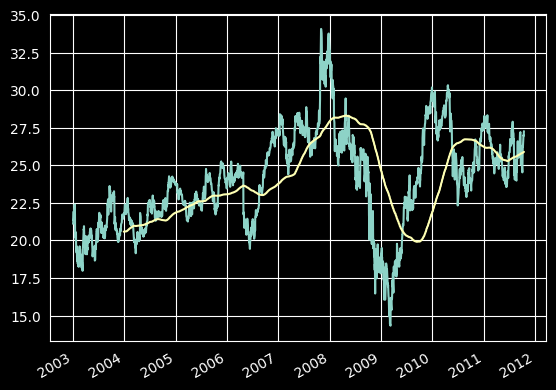

In [34]:
close_px_all = pd.read_csv("../data/stock.csv", parse_dates=True, index_col=0)
close_px = close_px_all["MSFT"]

# wykres ceny akcji
close_px.plot()
# średnia ruchoma
close_px.rolling(250).mean().plot()

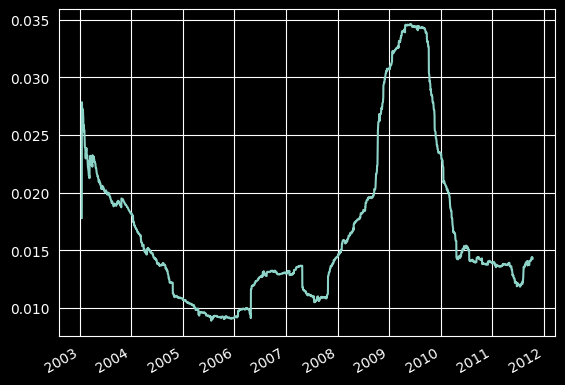

In [35]:
std250 = close_px.pct_change().rolling(250, min_periods=10).std()
#250-dniowe odchylenie standardowe dziennego zwrotu"
std250.plot()